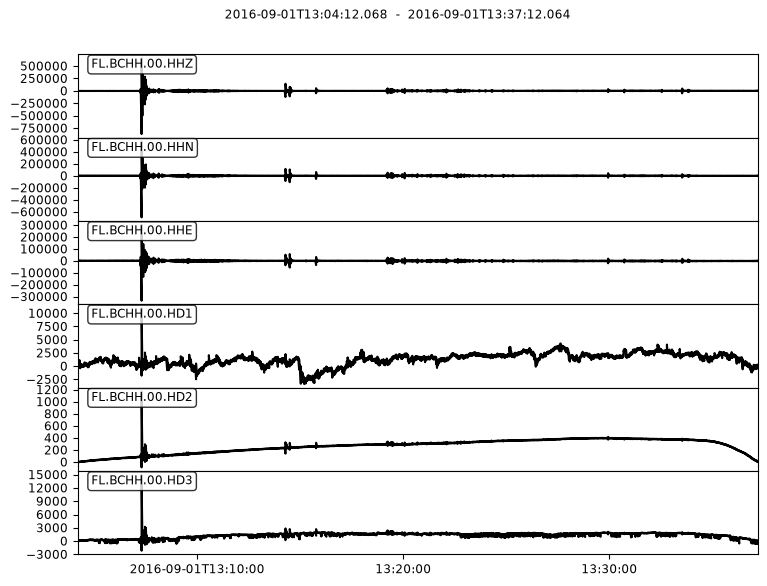

In [ ]:
from obspy import read, Stream, UTCDateTime
from pathlib import Path
miniseed_dir = Path('/Volumes/haldata/KSC/beforePASSCAL/EVENTS/20160901_SpaceXplosion')
OUTDIR = Path("/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing_papers_reports")
OUTDIR.mkdir(exist_ok=True)
mseed_outfile = OUTDIR / 'phase1234.mseed'
explosion_time = UTCDateTime("2016-09-01T13:07:12.066")
#st = read(miniseed_dir / 'explosion.mseed')

if mseed_outfile.exists():
    st = read(mseed_outfile)
else:
    st = Stream()
    mseedfiles = sorted(miniseed_dir.glob('*.20160901T000000'))
    for mseedfile in mseedfiles:
        st += read(mseedfile)
    st.trim(explosion_time - 180, explosion_time + 1800)
    st.write(mseed_outfile, format='MSEED')
    
#st.remove_response(output="VEL", pre_filt=(0.001, 0.005, 20, 25), water_level=60)
st.detrend()
st.plot(equal_scale=False, size=(800, 600));#, starttime=st[0].stats.starttime, endtime=st[0].stats.starttime + 60);